# Datos en Tiempo Real, Vendimias Históricas y el Test de Mankiw-Shapiro

**¿Cómo afectan las revisiones estadísticas al análisis macroeconómico y cómo podemos evaluar si las publicaciones iniciales reflejan pronósticos racionales ("News") o errores de medición ("Noise")?**

Los agregados macroeconómicos como el Producto Interno Bruto (PIB), el consumo y la inversión son revisados periódicamente por los institutos de estadística conforme se incorporan fuentes censales, registros administrativos y actualizaciones metodológicas:

1. **Información en Tiempo Real y Errores de Política**:
   Athanasios Orphanides (2001, *American Economic Review*) demostró que los errores de política monetaria en los años setenta se debieron a estimaciones de la brecha del producto sobre datos en tiempo real que sufrieron revisiones masivas posteriores. Croushore & Stark (2001, *Journal of Economic Literature*) formalizaron la arquitectura de datos en tiempo real.

2. **El Test Econométrico de Mankiw & Shapiro (1986)**:
   Sea $y_{0,t}$ la estimación inicial (avance) del crecimiento del PIB en el trimestre $t$, y $y_{T,t}$ la serie final revisada. La revisión total es:
   $$ r_t = y_{T,t} - y_{0,t} $$
   Mankiw & Shapiro (1986, *Journal of Business & Economic Statistics*) formulan la regresión MCO:
   $$ r_t = \alpha + \beta \, y_{0,t} + \varepsilon_t $$

   - **Hipótesis de Noticias (News, $\beta = 0$, $R^2 \approx 0$)**: La publicación inicial es un pronóstico condicional óptimo ($y_{0,t} = \mathbb{E}[y_{T,t} \mid \Omega_t]$). La revisión $r_t$ representa información estadística nueva y no correlacionada con $y_{0,t}$.
   - **Hipótesis de Ruido (Noise, $\beta = -1$, $\alpha = 0$)**: La publicación inicial contiene error de medición clásico ($y_{0,t} = y_{T,t} + v_t$, con $\text{Cov}(y_{T,t}, v_t) = 0$). Por lo tanto, $r_t = -v_t$ tiene correlación negativa con $y_{0,t}$.

En este cuaderno, exploramos las vendimias de Cuentas Nacionales Trimestrales (QNA) para más de 45 países, construimos triángulos de revisión $(T \times V)$, generamos cortes en tiempo real y ejecutamos el test de Mankiw-Shapiro con `puremacro.fetch` y `puremacro.vintages`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch import (
    get_qna_vintage_catalog,
    QNAVintagePanel,
)

## 1. Inspección del Catálogo de Vendimias QNA (45+ Países)

In [2]:
catalog = get_qna_vintage_catalog()
print(f"Total de series en el catálogo: {len(catalog)}")
print("\nMuestra de Entradas del Catálogo:")
print(catalog[["country", "country_name", "region", "variable", "series_id"]].head(10))

# Resumen por variable
var_counts = catalog.groupby("variable")["country"].count().reset_index()
var_counts.columns = ["Variable", "Número de Países"]
print("\nCobertura de Variables:")
print(var_counts)

Total de series en el catálogo: 360

Muestra de Entradas del Catálogo:
  country country_name            region      variable        series_id
0     AUS    Australia  OECD_AsiaPacific      con_real  NAEXKP02AUQ652S
1     AUS    Australia  OECD_AsiaPacific      deflator  CPALTT01AUQ659N
2     AUS    Australia  OECD_AsiaPacific  exports_real  NAEXKP06AUQ652S
3     AUS    Australia  OECD_AsiaPacific       gdp_nom  NAEXCP01AUQ652S
4     AUS    Australia  OECD_AsiaPacific      gdp_real  NAEXKP01AUQ652S
5     AUS    Australia  OECD_AsiaPacific     gfcf_real  NAEXKP04AUQ652S
6     AUS    Australia  OECD_AsiaPacific   govcon_real  NAEXKP03AUQ652S
7     AUS    Australia  OECD_AsiaPacific  imports_real  NAEXKP07AUQ652S
8     AUT      Austria       OECD_Europe      con_real  NAEXKP02ATQ652S
9     AUT      Austria       OECD_Europe      deflator  CPALTT01ATQ659N

Cobertura de Variables:
       Variable  Número de Países
0      con_real                45
1      deflator                45
2  exports

## 2. Construcción de un Panel de Vendimias en Tiempo Real

Simulamos una estructura de revisión realista para 4 países a lo largo de 40 trimestres ($T=40$) y 50 fechas de publicación ($V=50$).

In [3]:
rng = np.random.default_rng(1986)
n_quarters = 40
obs_dates = pd.date_range("2010-01-01", periods=n_quarters, freq="QS")
vintage_dates = pd.date_range("2010-04-01", periods=50, freq="QS")

countries = ["USA", "DEU", "GBR", "MEX"]
variables = ["gdp_real", "gfcf_real"]

records = []
for c in countries:
    for var in variables:
        true_growth = rng.normal(loc=2.2, scale=1.5, size=n_quarters)
        noise = rng.normal(loc=0.0, scale=0.6, size=n_quarters)
        y_0 = true_growth + noise
        
        for i, obs in enumerate(obs_dates):
            first_pub_idx = i + 1
            for j, vint in enumerate(vintage_dates):
                if j >= first_pub_idx:
                    lag = j - first_pub_idx
                    decay = np.exp(-lag / 3.0)
                    val = true_growth[i] + decay * noise[i]
                    records.append({
                        "country": c,
                        "variable": var,
                        "date": obs,
                        "vintage": vint,
                        "value": float(val),
                    })

df_raw = pd.DataFrame(records)
panel = QNAVintagePanel(df=df_raw)
print(f"Panel QNAVintagePanel creado con {len(df_raw):,} registros en {len(countries)} países.")

Panel QNAVintagePanel creado con 9,440 registros en 4 países.


## 3. Visualización del Triángulo de Revisión $(T \times V)$

In [4]:
tri_mex = panel.revision_matrix("MEX", "gdp_real")
print("Matriz de Revisión del PIB Real de México (primeros 6 trimestres × 6 vendimias):")
print(tri_mex.iloc[:6, :6])

Matriz de Revisión del PIB Real de México (primeros 6 trimestres × 6 vendimias):
vintage     2010-07-01  2010-10-01  2011-01-01  2011-04-01  2011-07-01  \
date                                                                     
2010-01-01    1.947097    1.846378    1.774209    1.722498    1.685446   
2010-04-01         NaN    1.702149    1.922618    2.080592    2.193784   
2010-07-01         NaN         NaN    2.165770    2.393266    2.556274   
2010-10-01         NaN         NaN         NaN    2.634212    2.479038   
2011-01-01         NaN         NaN         NaN         NaN    0.069245   
2011-04-01         NaN         NaN         NaN         NaN         NaN   

vintage     2011-10-01  
date                    
2010-01-01    1.658897  
2010-04-01    2.274891  
2010-07-01    2.673075  
2010-10-01    2.367852  
2011-01-01    0.209078  
2011-04-01    1.006397  


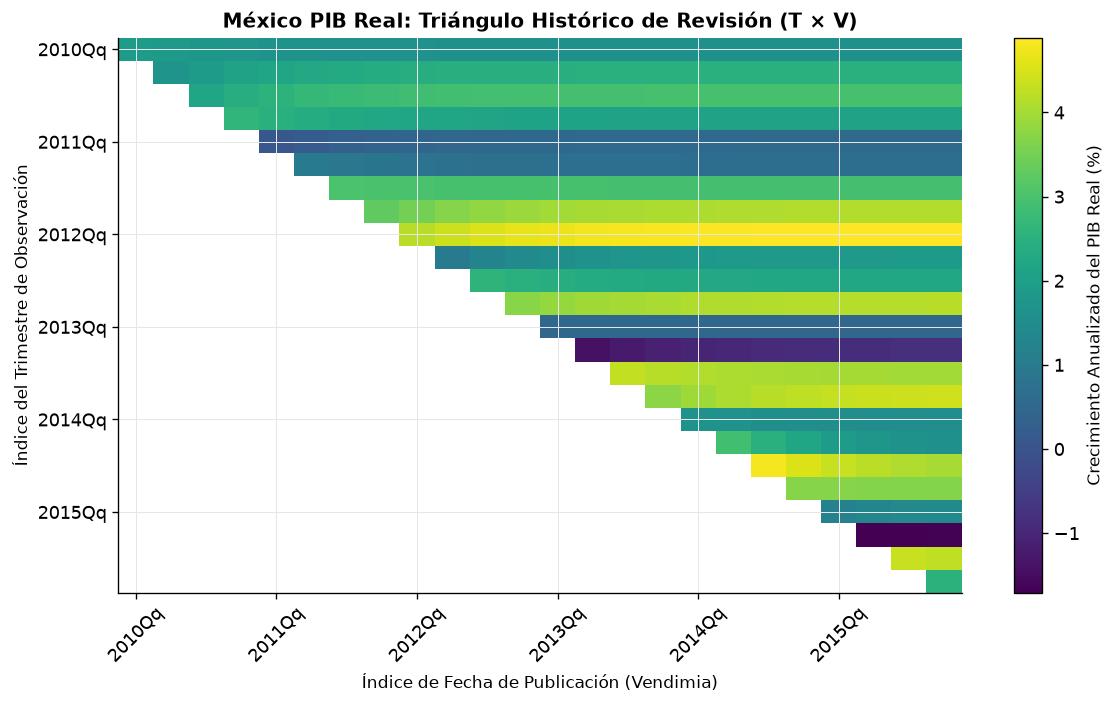

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tri_mex.iloc[:24, :24].to_numpy(), cmap="viridis", aspect="auto")
ax.set_title("México PIB Real: Triángulo Histórico de Revisión (T × V)", fontsize=12, fontweight="bold")
ax.set_xlabel("Índice de Fecha de Publicación (Vendimia)", fontsize=10)
ax.set_ylabel("Índice del Trimestre de Observación", fontsize=10)

ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([d.strftime("%YQ%q") for d in tri_mex.columns[:24:4]], rotation=45)
ax.set_yticks(range(0, 24, 4))
ax.set_yticklabels([d.strftime("%YQ%q") for d in tri_mex.index[:24:4]])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Crecimiento Anualizado del PIB Real (%)", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Primera Estimación (Avance) vs. Última Revisión

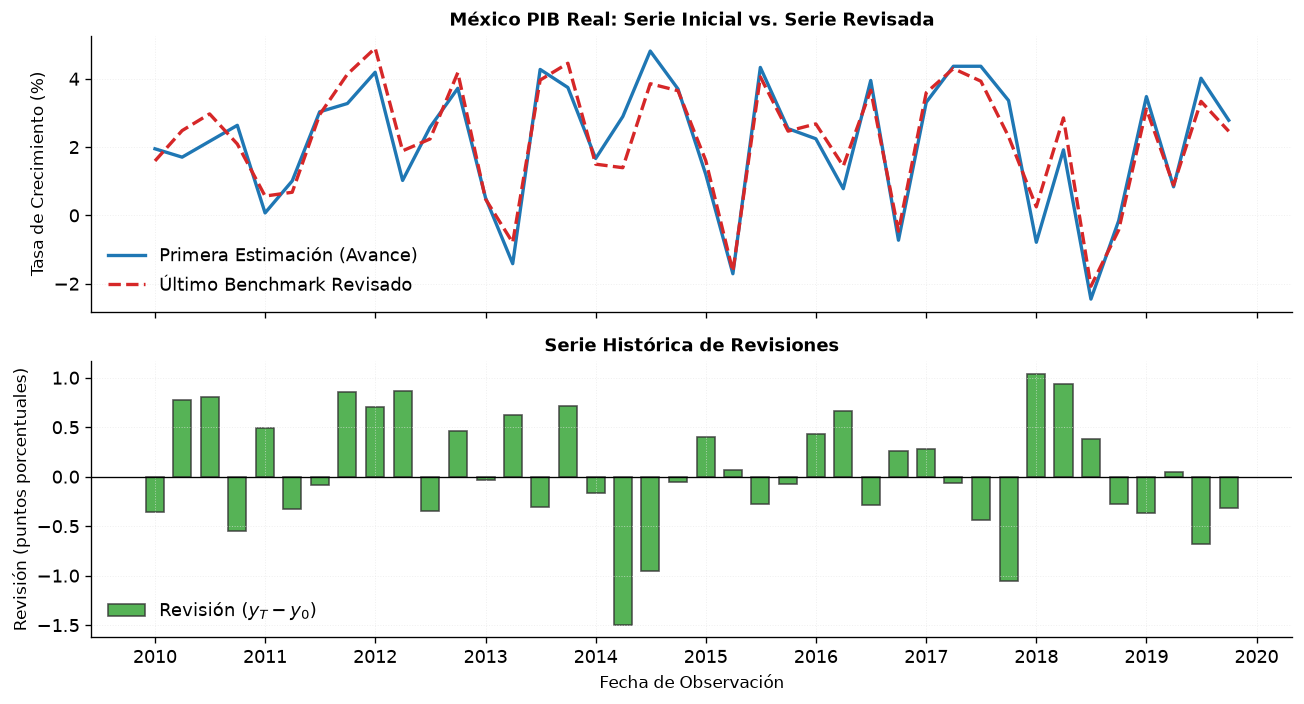

In [6]:
s_first = panel.first_release("MEX", "gdp_real")
s_latest = panel.latest_release("MEX", "gdp_real")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(s_first.index, s_first.values, color="#1f77b4", lw=2, label="Primera Estimación (Avance)")
ax1.plot(s_latest.index, s_latest.values, color="#d62728", lw=2, linestyle="--", label="Último Benchmark Revisado")
ax1.set_title("México PIB Real: Serie Inicial vs. Serie Revisada", fontsize=11, fontweight="bold")
ax1.set_ylabel("Tasa de Crecimiento (%)", fontsize=10)
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

revision = s_latest - s_first
ax2.bar(revision.index, revision.values, color="#2ca02c", width=60, edgecolor="#333", alpha=0.8, label="Revisión ($y_T - y_0$)")
ax2.axhline(0, color="black", lw=0.8, linestyle="-")
ax2.set_title("Serie Histórica de Revisiones", fontsize=11, fontweight="bold")
ax2.set_xlabel("Fecha de Observación", fontsize=10)
ax2.set_ylabel("Revisión (puntos porcentuales)", fontsize=10)
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Ejecución del Test de Mankiw-Shapiro (1986)

In [7]:
stats_mex = panel.revision_stats("MEX", "gdp_real")
print("==================================================================")
print("  TEST ECONOMÉTRICO DE NOTICIAS VS RUIDO DE MANKIW Y SHAPIRO (1986)")
print("==================================================================")
print(f"País:                  México (MEX)")
print(f"Variable:              PIB Real (gdp_real)")
print(f"Tamaño Muestral (N):   {stats_mex['n_obs']}")
print(f"Revisión Media (alpha):{stats_mex['mean_revision']:.4f}")
print(f"Revisión Abs. Media:   {stats_mex['abs_mean_revision']:.4f}")
print(f"Desv. Est. Revisión:   {stats_mex['std_revision']:.4f}")
print("------------------------------------------------------------------")
print(f"Constante MCO (alpha): {stats_mex['mankiw_shapiro_alpha']:.4f}")
print(f"Pendiente MCO (beta):  {stats_mex['mankiw_shapiro_beta']:.4f}")
print(f"Error Estándar (SE):   {stats_mex['mankiw_shapiro_se']:.4f}")
print(f"Estadístico t:         {stats_mex['mankiw_shapiro_tstat']:.4f}")
print(f"Valor p:               {stats_mex['mankiw_shapiro_pvalue']:.4f}")
print(f"Conclusión:            {stats_mex['hypothesis']}")
print("==================================================================")

  TEST ECONOMÉTRICO DE NOTICIAS VS RUIDO DE MANKIW Y SHAPIRO (1986)
País:                  México (MEX)
Variable:              PIB Real (gdp_real)
Tamaño Muestral (N):   40
Revisión Media (alpha):0.0574
Revisión Abs. Media:   0.4829
Desv. Est. Revisión:   0.5922
------------------------------------------------------------------
Constante MCO (alpha): 0.3099
Pendiente MCO (beta):  -0.1187
Error Estándar (SE):   0.0473
Estadístico t:         -2.5103
Valor p:               0.0121
Conclusión:            mixed


In [8]:
# Resumen para todos los países
results_all = []
for c in countries:
    for v in variables:
        st = panel.revision_stats(c, v)
        results_all.append({
            "País": c,
            "Variable": v,
            "N": st["n_obs"],
            "Revisión Media": st["mean_revision"],
            "Desv. Est.": st["std_revision"],
            "Beta": st["mankiw_shapiro_beta"],
            "t-stat": st["mankiw_shapiro_tstat"],
            "p-value": st["mankiw_shapiro_pvalue"],
            "Hipótesis": st["hypothesis"],
        })

df_test_summary = pd.DataFrame(results_all)
print("\nTabla Resumen del Test de Mankiw-Shapiro por País:")
print(df_test_summary.to_string(index=False))


Tabla Resumen del Test de Mankiw-Shapiro por País:
País  Variable  N  Revisión Media  Desv. Est.      Beta    t-stat      p-value Hipótesis
 USA  gdp_real 40        0.128552    0.522568 -0.047651 -0.844770 3.982394e-01      news
 USA gfcf_real 40        0.168940    0.607311 -0.156902 -3.137369 1.704712e-03     mixed
 DEU  gdp_real 40       -0.038504    0.671448 -0.096211 -1.425615 1.539794e-01      news
 DEU gfcf_real 40        0.079058    0.771028 -0.243094 -4.040550 5.332605e-05     mixed
 GBR  gdp_real 40       -0.044003    0.616643 -0.212660 -5.507966 3.630036e-08     mixed
 GBR gfcf_real 40        0.055347    0.682129 -0.108487 -1.357966 1.744746e-01      news
 MEX  gdp_real 40        0.057448    0.592209 -0.118650 -2.510331 1.206181e-02     mixed
 MEX gfcf_real 40       -0.069313    0.591366 -0.193343 -3.982972 6.805891e-05     mixed


## 6. Gráfico Diagnóstico de la Regresión de Mankiw-Shapiro

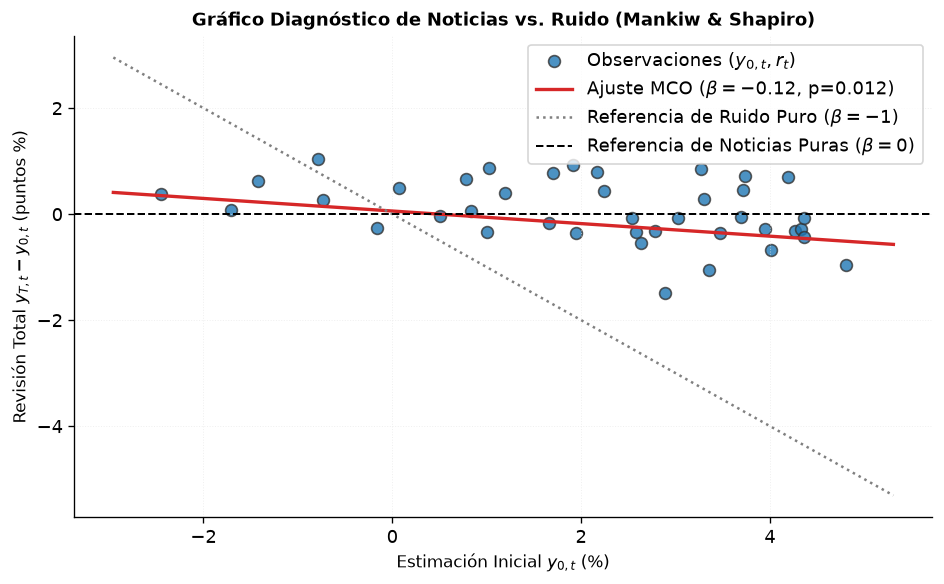

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

x_vals = s_first.values
y_vals = (s_latest - s_first).values
ax.scatter(x_vals, y_vals, color="#1f77b4", edgecolors="#333", s=50, alpha=0.8, label="Observaciones ($y_{0,t}, r_t$)")

x_grid = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 100)
y_fit = stats_mex["mean_revision"] + stats_mex["mankiw_shapiro_beta"] * x_grid
ax.plot(x_grid, y_fit, color="#d62728", lw=2, label=f"Ajuste MCO ($\\beta={stats_mex['mankiw_shapiro_beta']:.2f}$, p={stats_mex['mankiw_shapiro_pvalue']:.3f})")

y_noise = -1.0 * x_grid
ax.plot(x_grid, y_noise, color="gray", lw=1.5, linestyle=":", label="Referencia de Ruido Puro ($\\beta=-1$)")
ax.axhline(0, color="black", lw=1.2, linestyle="--", label="Referencia de Noticias Puras ($\\beta=0$)")

ax.set_title("Gráfico Diagnóstico de Noticias vs. Ruido (Mankiw & Shapiro)", fontsize=11, fontweight="bold")
ax.set_xlabel("Estimación Inicial $y_{0,t}$ (%)", fontsize=10)
ax.set_ylabel("Revisión Total $y_{T,t} - y_{0,t}$ (puntos %)", fontsize=10)
ax.legend(loc="upper right", frameon=True)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 7. Cortes en Tiempo Real del Panel (`.as_of()`)

In [10]:
df_2018 = panel.as_of("2018-04-01")
print("Panel de Corte en Tiempo Real al 2018-04-01:")
print(df_2018.head(10))

Panel de Corte en Tiempo Real al 2018-04-01:
                    gdp_real  gfcf_real
country date                           
DEU     2010-01-01  3.512874   5.579053
        2010-04-01  3.818080   1.555937
        2010-07-01  4.513233   3.497328
        2010-10-01  1.570123   1.341830
        2011-01-01  2.528645   1.250250
        2011-04-01  0.174395   1.466107
        2011-07-01  3.138878   1.371857
        2011-10-01  2.482929   4.079837
        2012-01-01  0.918204   3.051182
        2012-04-01  6.050661   3.831781
